In [7]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

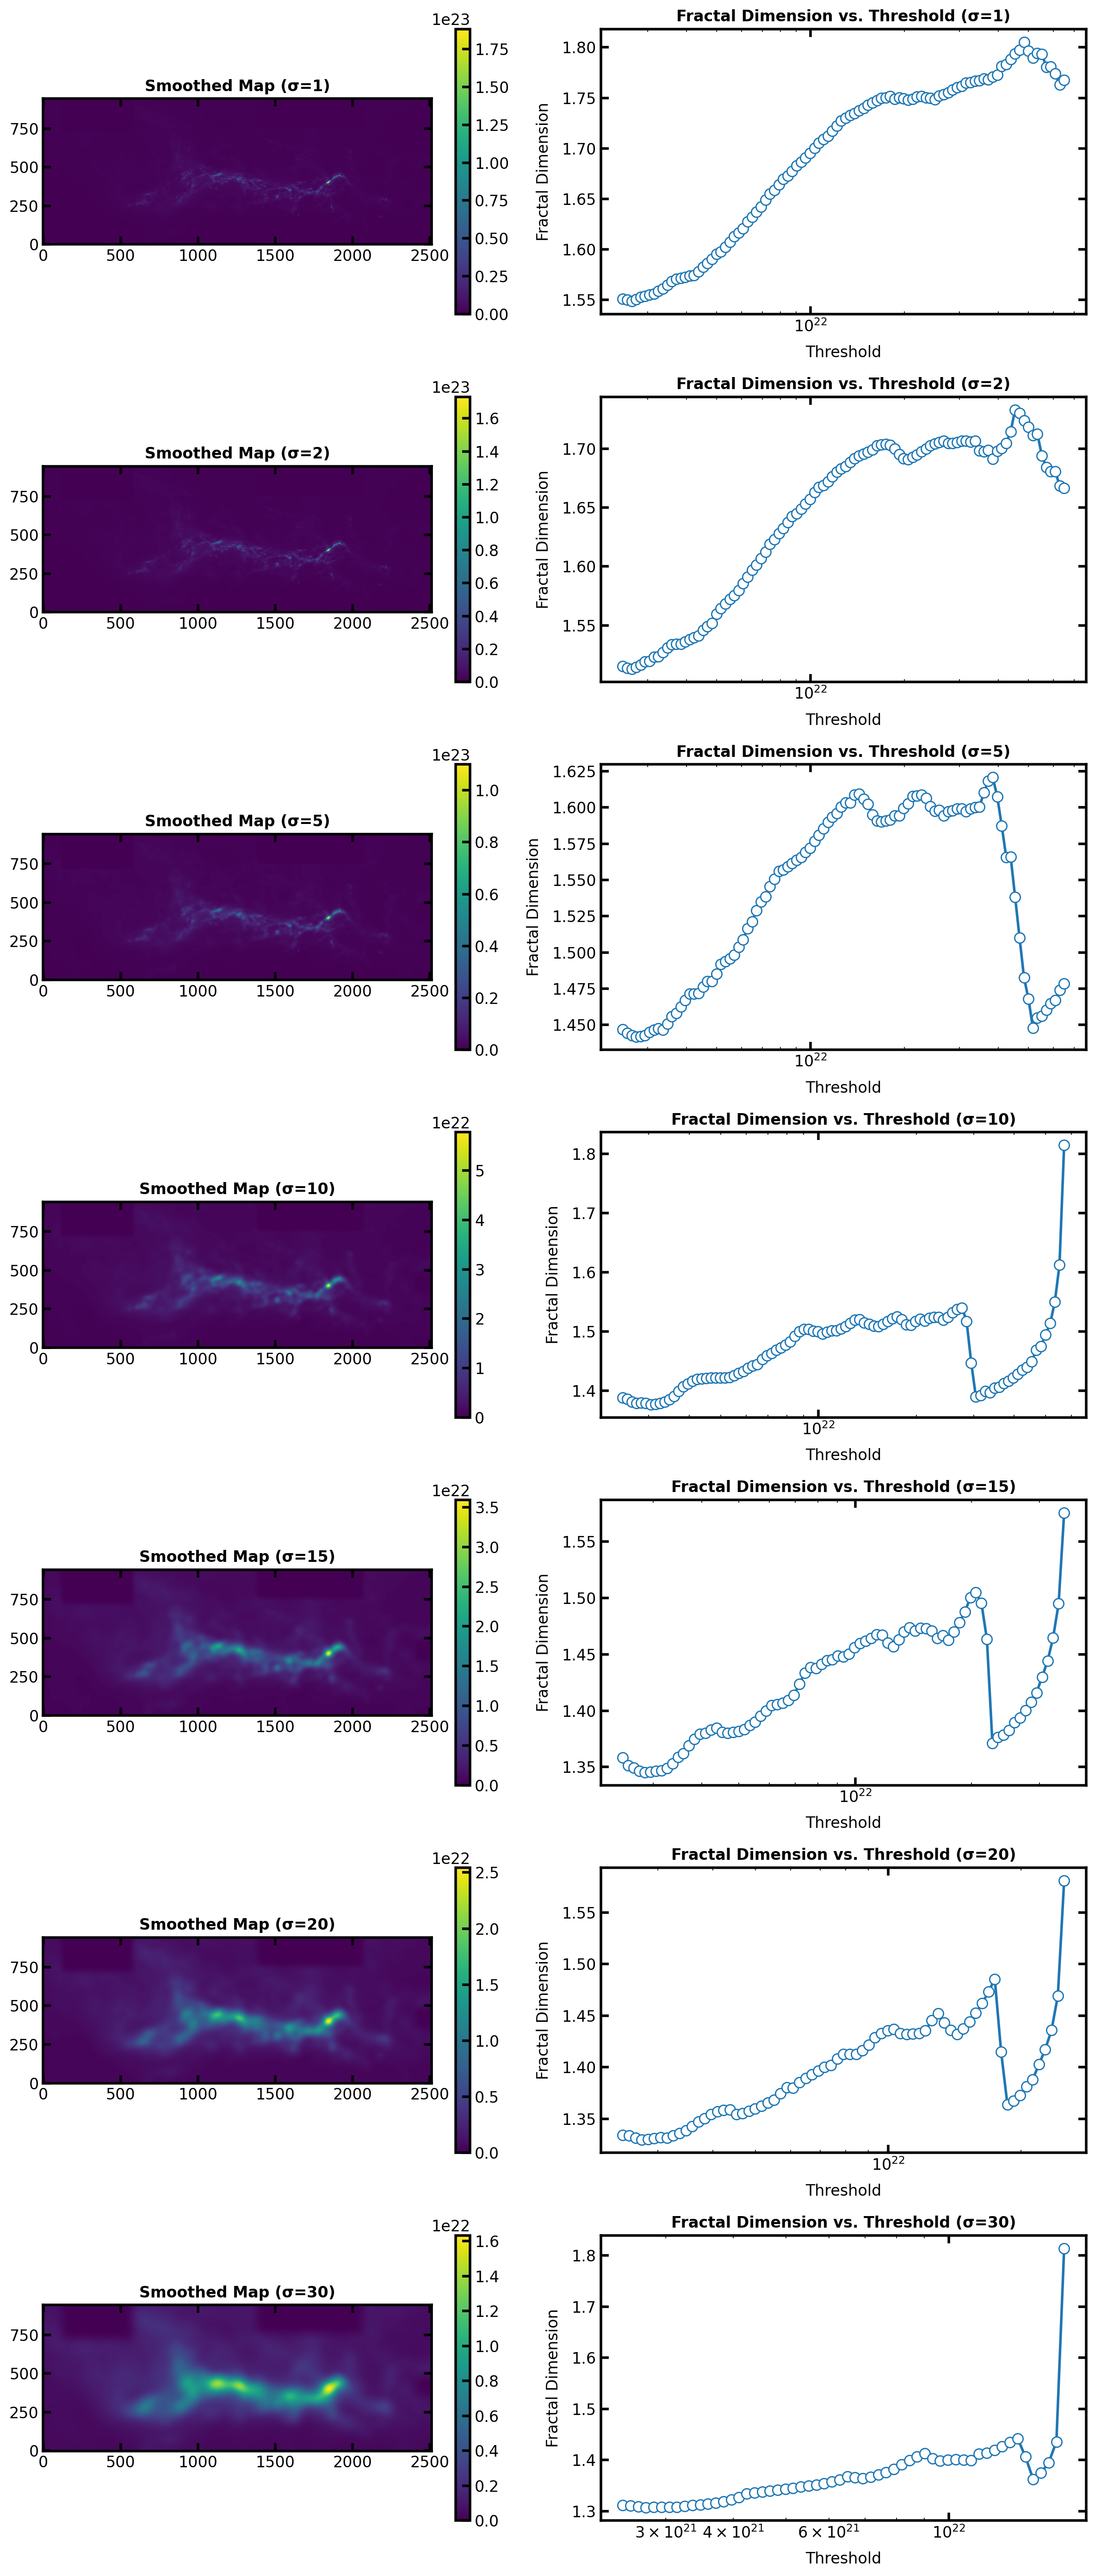

In [17]:
threshold_min = 2.5e21
threshold_max = 6.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

# Define standard deviations for Gaussian smoothing
sigma_values = [1, 2, 5, 10, 15, 20, 30]

# Store results for each smoothed version
results_smoothed = {}

for sigma in sigma_values:
    # Apply Gaussian smoothing
    smoothed_data = gaussian_filter(N_H2_OA, sigma=sigma)
    
    # Run standard Minkowski functionals on the smoothed data
    results_smoothed[sigma] = standard_minkowski_functionals(smoothed_data, threshold_min=threshold_min, threshold_max=threshold_max)

# Now `results_smoothed` contains the results for each level of smoothing
fig, axes = plt.subplots(len(sigma_values), 2, figsize=(12, 4 * len(sigma_values)))

normal_thresholds = np.linspace(threshold_min, threshold_max, 100)

for i, sigma in enumerate(sigma_values):
    smoothed_data = gaussian_filter(N_H2_OA, sigma=sigma)
    results = results_smoothed[sigma]
    
    # Plot the smoothed map
    ax1 = axes[i, 0]
    im = ax1.imshow(smoothed_data, origin='lower', cmap='viridis')
    ax1.set_title(f"Smoothed Map (σ={sigma})", fontweight='bold')
    plt.colorbar(im, ax=ax1, orientation='vertical')
    
    # Plot fractal dimension vs thresholds
    ax2 = axes[i, 1]
    ax2.plot(results["thresholds"], results["fractal_dimension"], 'o-')
    ax2.set_title(f"Fractal Dimension vs. Threshold (σ={sigma})", fontweight='bold')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Fractal Dimension')
    ax2.set_xscale("log")

plt.tight_layout()
plt.show()

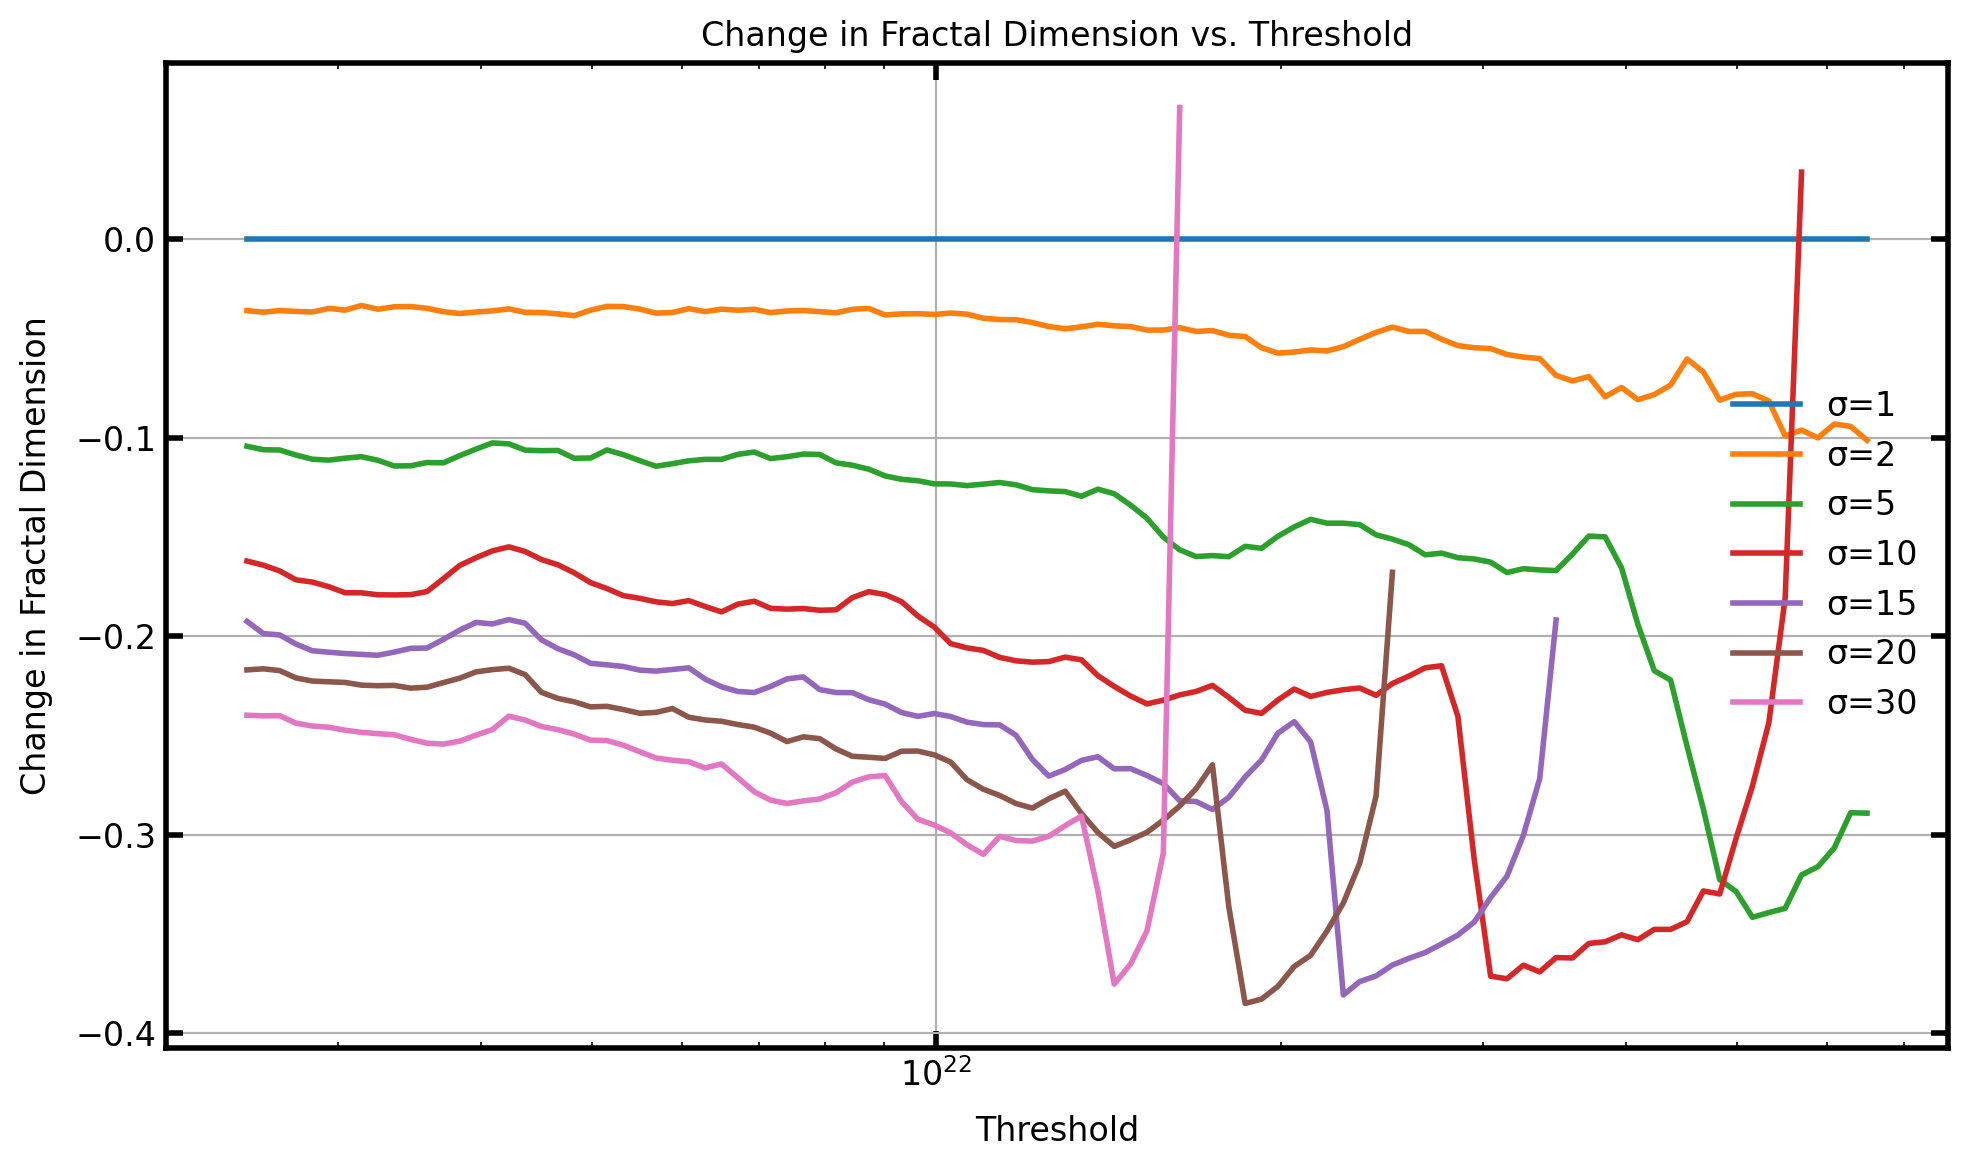

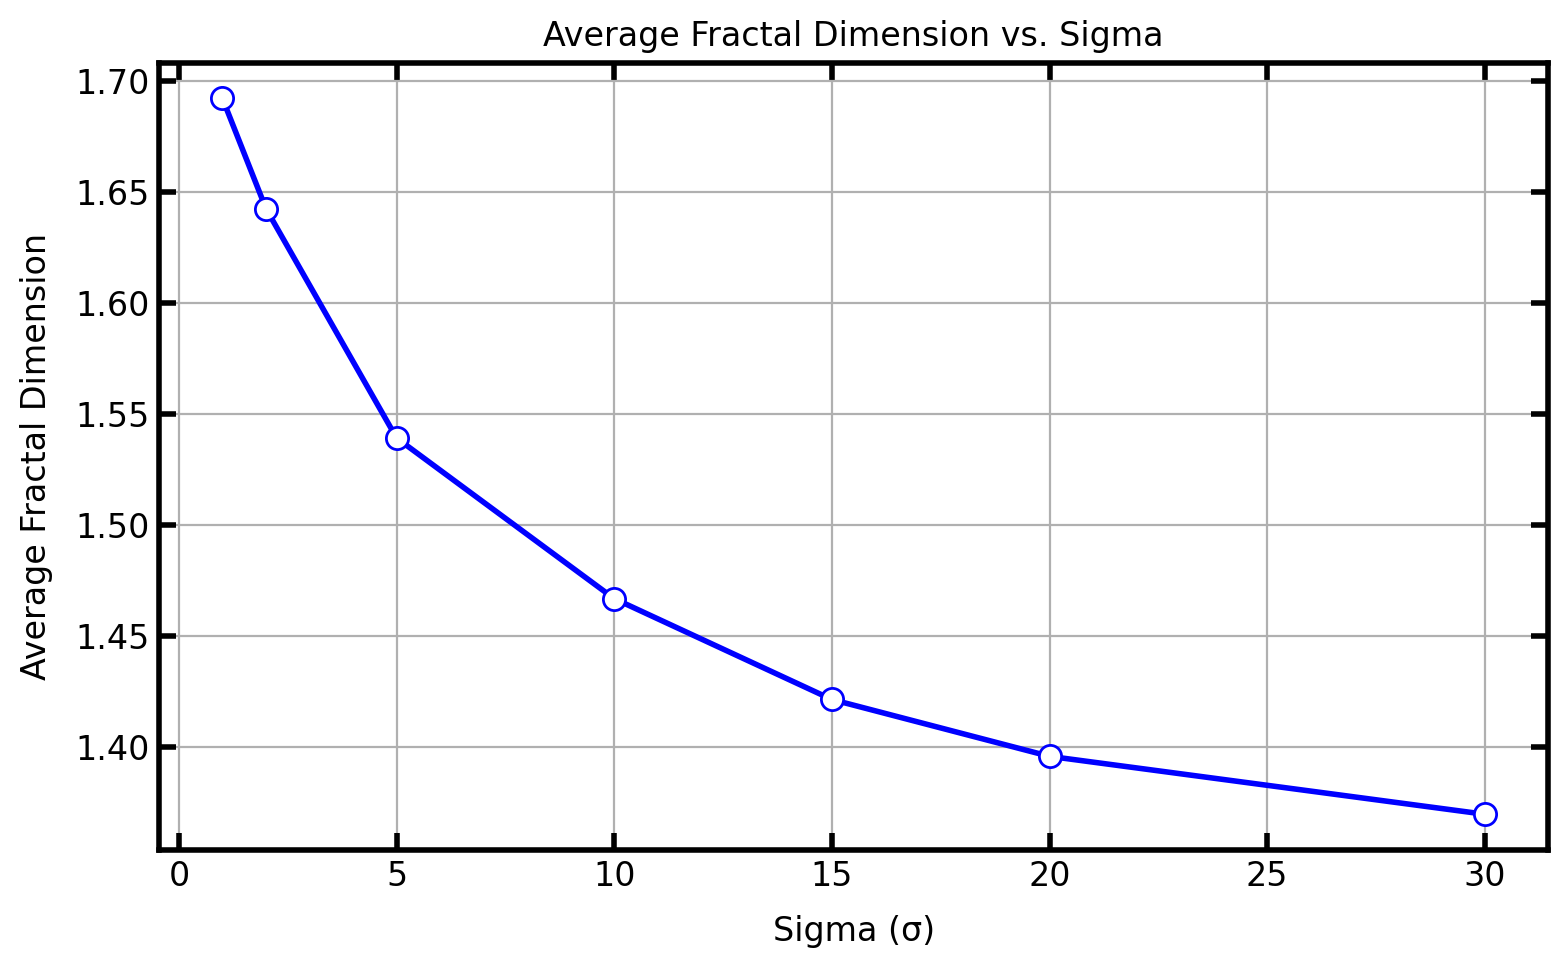

Sigma: 1
Average Fractal Dimension: 1.6920
Mean Change: 0.0000
Max Change: 0.0000
Min Change: 0.0000
Percentage Change (Mean): 0.00%

Sigma: 2
Average Fractal Dimension: 1.6423
Mean Change: -0.0496
Max Change: -0.0333
Min Change: -0.1013
Percentage Change (Mean): -2.93%

Sigma: 5
Average Fractal Dimension: 1.5390
Mean Change: -0.1529
Max Change: -0.1026
Min Change: -0.3417
Percentage Change (Mean): -9.04%

Sigma: 10
Average Fractal Dimension: 1.4667
Mean Change: -0.2220
Max Change: 0.0338
Min Change: -0.3727
Percentage Change (Mean): -13.12%

Sigma: 15
Average Fractal Dimension: 1.4213
Mean Change: -0.2494
Max Change: -0.1917
Min Change: -0.3808
Percentage Change (Mean): -14.74%

Sigma: 20
Average Fractal Dimension: 1.3957
Mean Change: -0.2624
Max Change: -0.1678
Min Change: -0.3851
Percentage Change (Mean): -15.51%

Sigma: 30
Average Fractal Dimension: 1.3696
Mean Change: -0.2679
Max Change: 0.0664
Min Change: -0.3754
Percentage Change (Mean): -15.83%



In [21]:
# Extract the "ground truth" fractal dimension from the un-smoothed data
ground_truth_fractal_dimension = results_smoothed[1]["fractal_dimension"]

# Calculate the change in fractal dimension for each sigma
fractal_dimension_changes = {}
averages = {}
for sigma in sigma_values:
    smoothed_fractal_dimension = results_smoothed[sigma]["fractal_dimension"]
    averages[sigma] = np.nanmean(smoothed_fractal_dimension)
    fractal_dimension_changes[sigma] = smoothed_fractal_dimension - ground_truth_fractal_dimension

# Plot the change in fractal dimension
plt.figure(figsize=(10, 6))
for sigma, changes in fractal_dimension_changes.items():
    plt.plot(results_smoothed[sigma]["thresholds"], changes, label=f"σ={sigma}")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Change in Fractal Dimension")
plt.title("Change in Fractal Dimension vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Plot the average fractal dimension for the different sigmas
plt.figure(figsize=(8, 5))
plt.plot(sigma_values, [averages[sigma] for sigma in sigma_values], marker='o', linestyle='-', color='b')
plt.xlabel('Sigma (σ)')
plt.ylabel('Average Fractal Dimension')
plt.title('Average Fractal Dimension vs. Sigma')
plt.grid(True)
plt.show()

# Print some data
for sigma, changes in fractal_dimension_changes.items():
    mean_change = np.nanmean(changes)
    max_change = np.nanmax(changes)
    min_change = np.nanmin(changes)
    percentage_change = (mean_change / np.nanmean(ground_truth_fractal_dimension)) * 100
    
    print(f"Sigma: {sigma}")
    print(f"Average Fractal Dimension: {np.average(averages[sigma]):.4f}")
    print(f"Mean Change: {mean_change:.4f}")
    print(f"Max Change: {max_change:.4f}")
    print(f"Min Change: {min_change:.4f}")
    print(f"Percentage Change (Mean): {percentage_change:.2f}%")
    print()

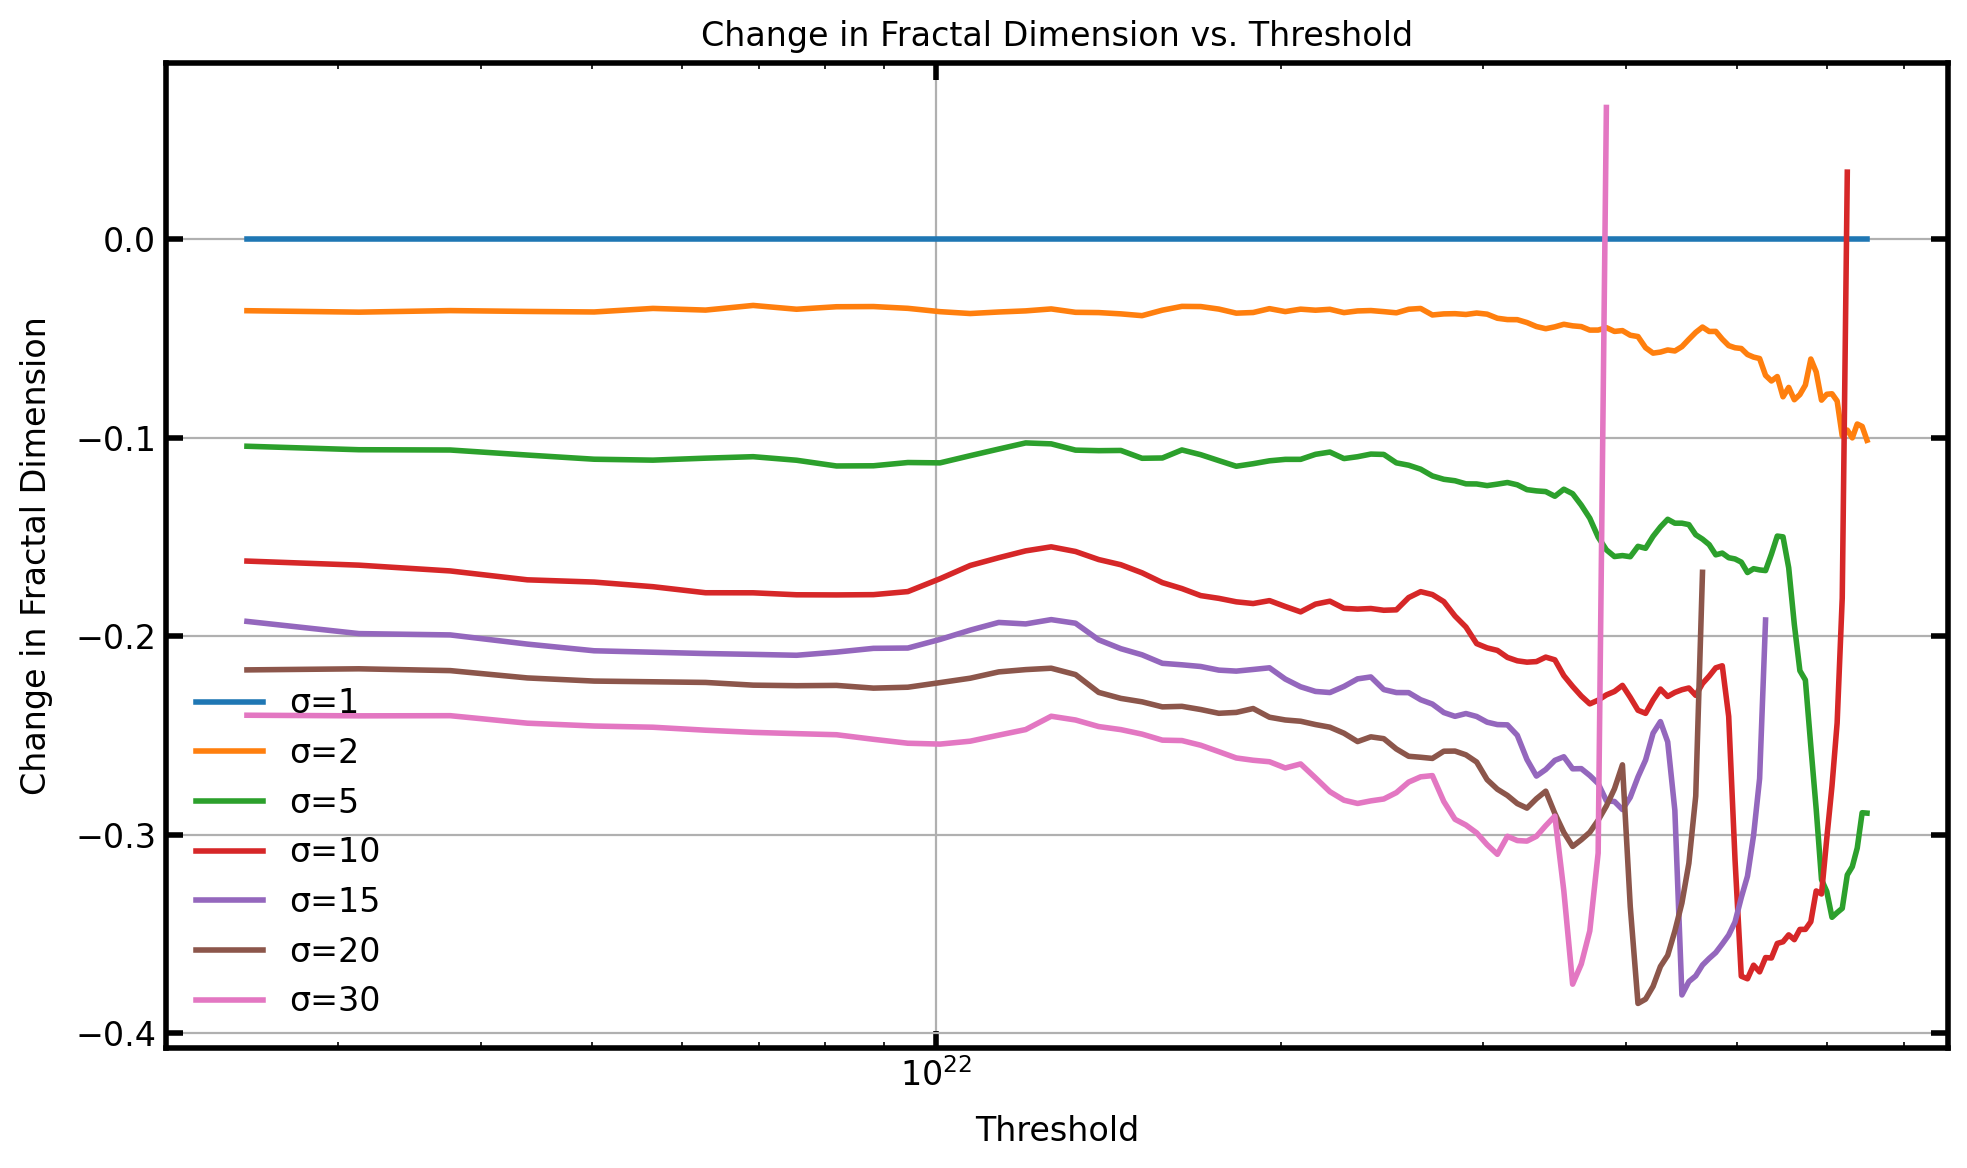

Sigma: 1
Average Fractal Dimension: 1.6920
Mean Change: 0.0000
Max Change: 0.0000
Min Change: 0.0000
Percentage Change (Mean): 0.00%

Sigma: 2
Average Fractal Dimension: 1.6423
Mean Change: -0.0496
Max Change: -0.0333
Min Change: -0.1013
Percentage Change (Mean): -2.93%

Sigma: 5
Average Fractal Dimension: 1.5390
Mean Change: -0.1529
Max Change: -0.1026
Min Change: -0.3417
Percentage Change (Mean): -9.04%

Sigma: 10
Average Fractal Dimension: 1.4667
Mean Change: -0.2220
Max Change: 0.0338
Min Change: -0.3727
Percentage Change (Mean): -13.12%

Sigma: 15
Average Fractal Dimension: 1.4213
Mean Change: -0.2494
Max Change: -0.1917
Min Change: -0.3808
Percentage Change (Mean): -14.74%

Sigma: 20
Average Fractal Dimension: 1.3957
Mean Change: -0.2624
Max Change: -0.1678
Min Change: -0.3851
Percentage Change (Mean): -15.51%

Sigma: 30
Average Fractal Dimension: 1.3696
Mean Change: -0.2679
Max Change: 0.0664
Min Change: -0.3754
Percentage Change (Mean): -15.83%



In [20]:
# Extract the "ground truth" fractal dimension from the un-smoothed data
ground_truth_fractal_dimension = results_smoothed[1]["fractal_dimension"]

normal_thresholds = np.linspace(threshold_min, threshold_max, 100)

# Calculate the change in fractal dimension for each sigma
fractal_dimension_changes = {}
averages = {}
for sigma in sigma_values:
    smoothed_fractal_dimension = results_smoothed[sigma]["fractal_dimension"]
    averages[sigma] = np.nanmean(smoothed_fractal_dimension)
    fractal_dimension_changes[sigma] = smoothed_fractal_dimension - ground_truth_fractal_dimension

# Plot the change in fractal dimension
plt.figure(figsize=(10, 6))
for sigma, changes in fractal_dimension_changes.items():
    plt.plot(normal_thresholds, changes, label=f"σ={sigma}")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Change in Fractal Dimension")
plt.title("Change in Fractal Dimension vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Print some data
for sigma, changes in fractal_dimension_changes.items():
    mean_change = np.nanmean(changes)
    max_change = np.nanmax(changes)
    min_change = np.nanmin(changes)
    percentage_change = (mean_change / np.nanmean(ground_truth_fractal_dimension)) * 100
    
    print(f"Sigma: {sigma}")
    print(f"Average Fractal Dimension: {np.average(averages[sigma]):.4f}")
    print(f"Mean Change: {mean_change:.4f}")
    print(f"Max Change: {max_change:.4f}")
    print(f"Min Change: {min_change:.4f}")
    print(f"Percentage Change (Mean): {percentage_change:.2f}%")
    print()

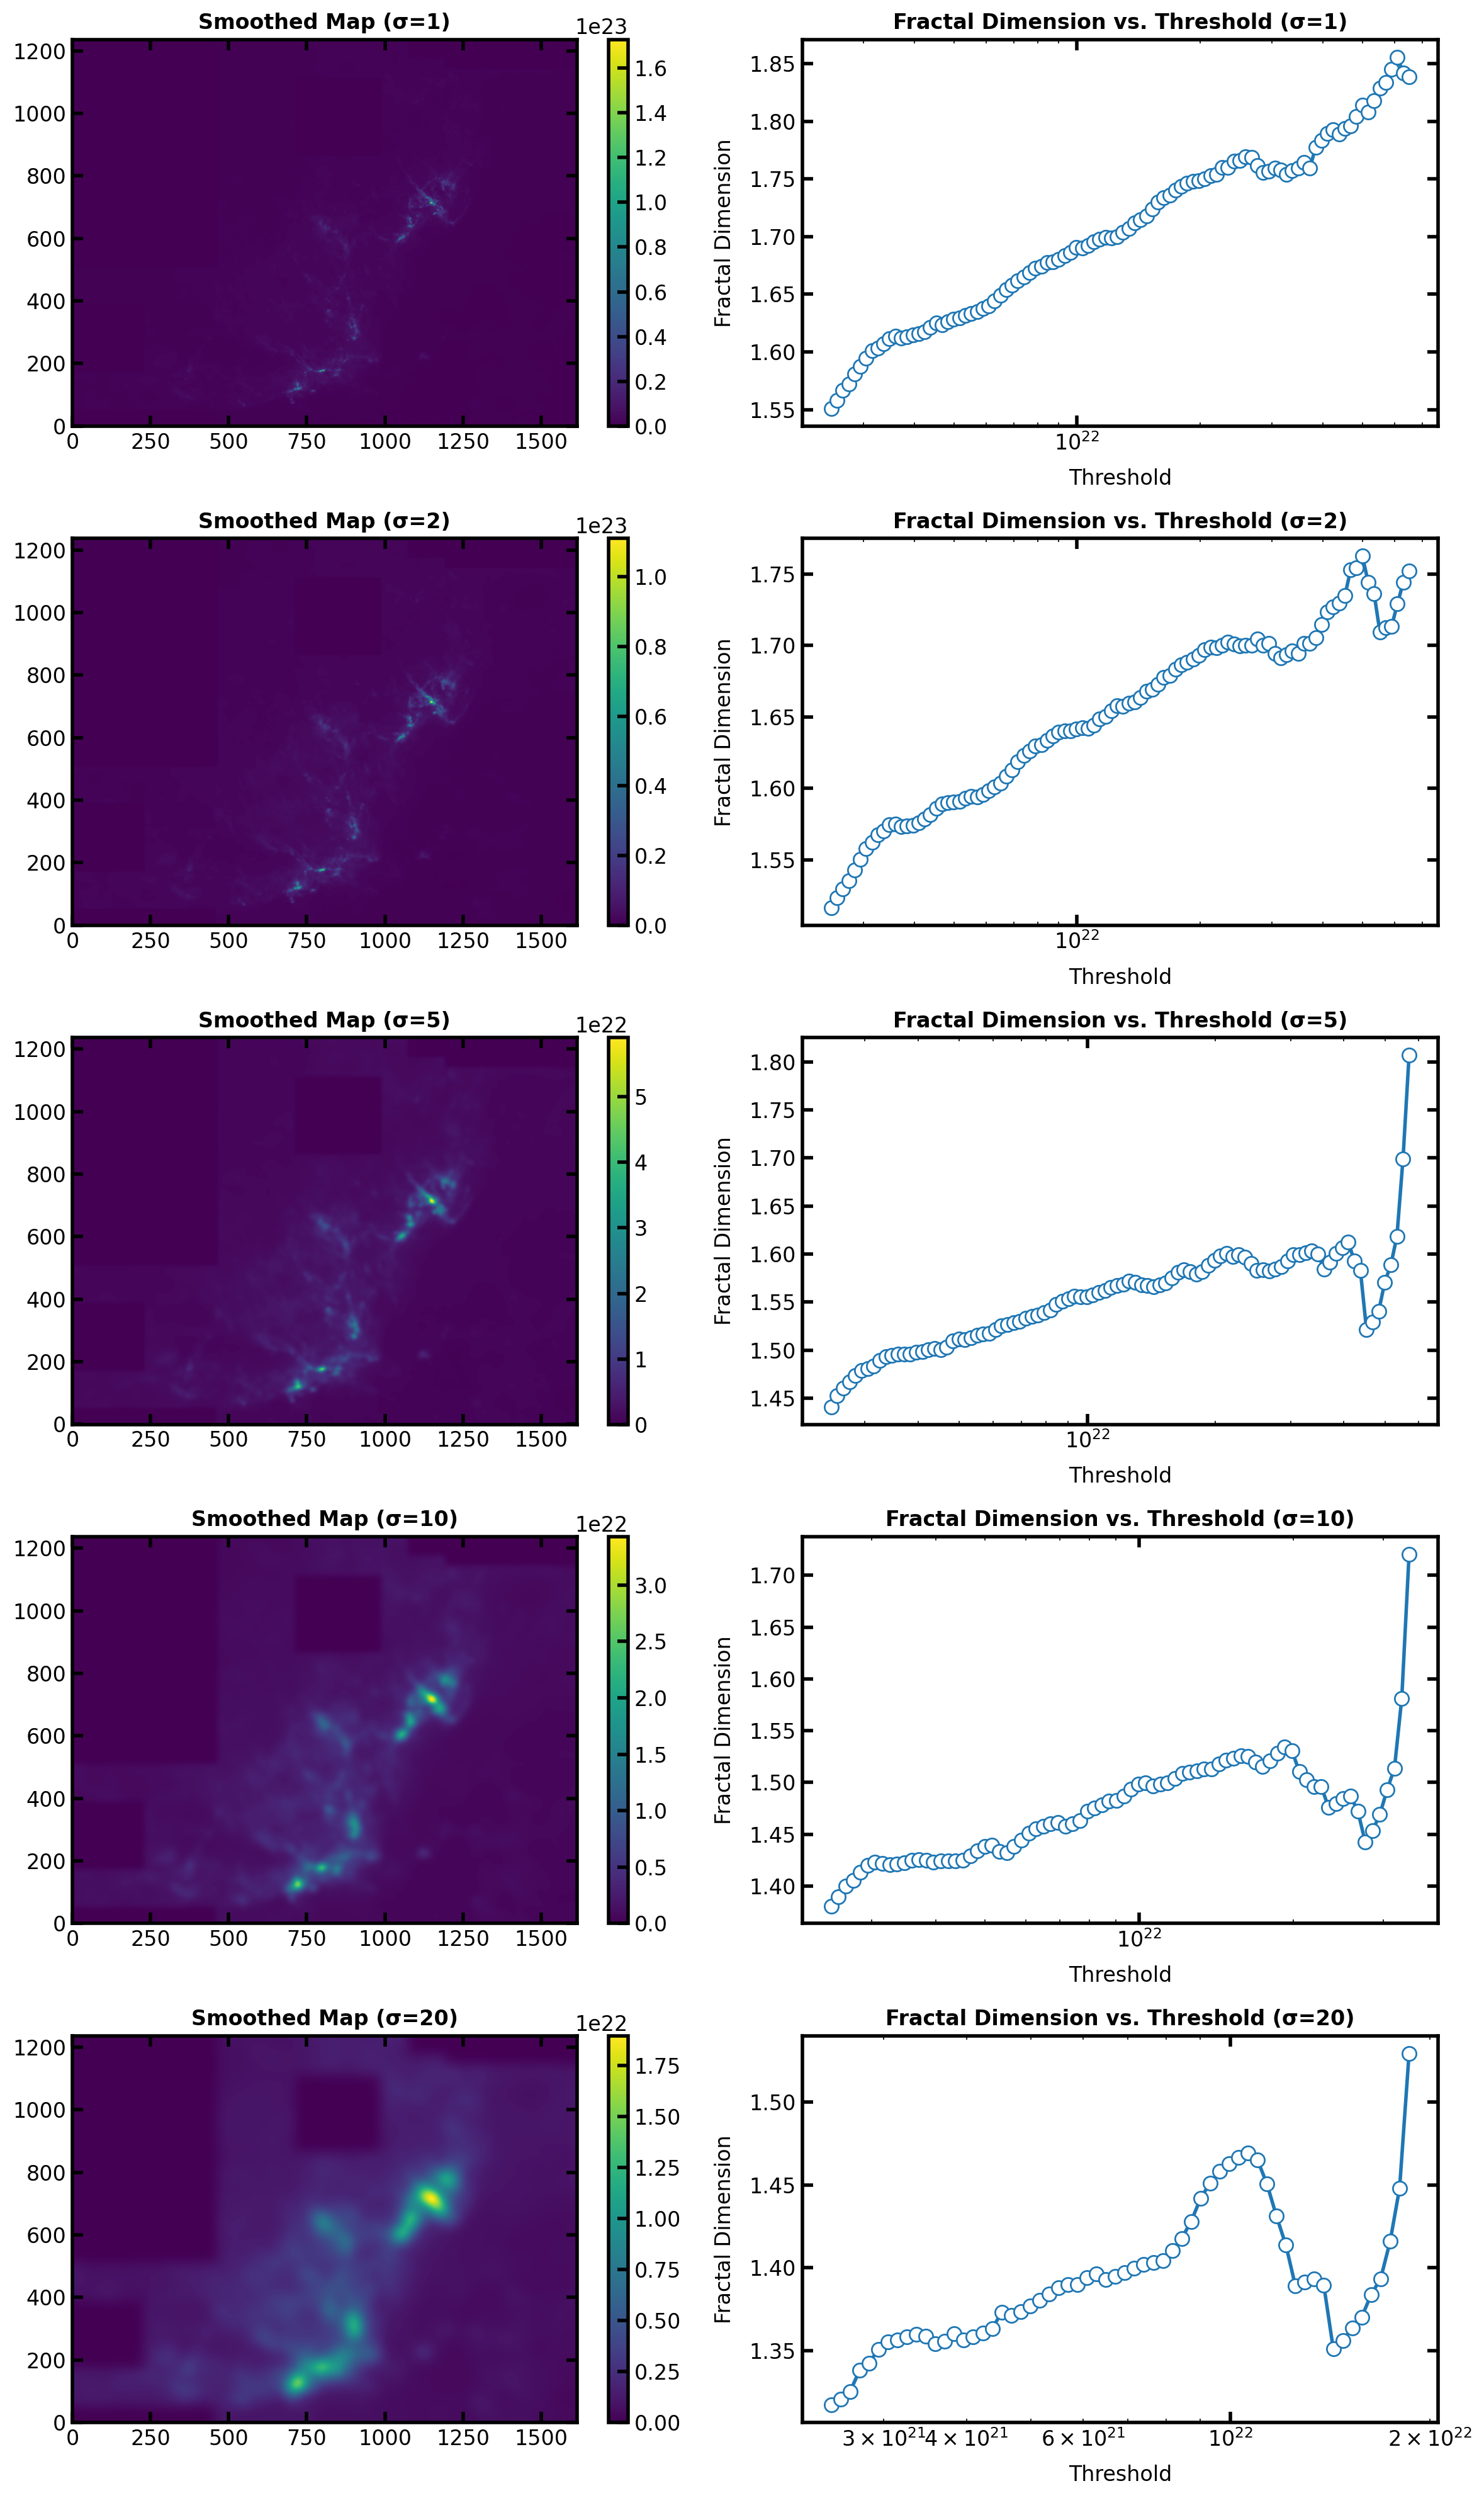

In [5]:
threshold_min = 2.5e21
threshold_max = 6.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

# Define standard deviations for Gaussian smoothing
sigma_values = [1, 2, 5, 10, 20]

# Store results for each smoothed version
results_smoothed = {}

for sigma in sigma_values:
    # Apply Gaussian smoothing
    smoothed_data = gaussian_filter(N_H2_OB, sigma=sigma)
    
    # Run standard Minkowski functionals on the smoothed data
    results_smoothed[sigma] = standard_minkowski_functionals(smoothed_data, threshold_min=threshold_min, threshold_max=threshold_max)

# Now `results_smoothed` contains the results for each level of smoothing
fig, axes = plt.subplots(len(sigma_values), 2, figsize=(12, 4 * len(sigma_values)))

for i, sigma in enumerate(sigma_values):
    smoothed_data = gaussian_filter(N_H2_OB, sigma=sigma)
    results = results_smoothed[sigma]
    
    # Plot the smoothed map
    ax1 = axes[i, 0]
    im = ax1.imshow(smoothed_data, origin='lower', cmap='viridis')
    ax1.set_title(f"Smoothed Map (σ={sigma})", fontweight='bold')
    plt.colorbar(im, ax=ax1, orientation='vertical')
    
    # Plot fractal dimension vs thresholds
    ax2 = axes[i, 1]
    ax2.plot(results["thresholds"], results["fractal_dimension"], 'o-')
    ax2.set_title(f"Fractal Dimension vs. Threshold (σ={sigma})", fontweight='bold')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Fractal Dimension')
    ax2.set_xscale("log")

plt.tight_layout()
plt.show()